# Method B — α_r 분화 개선 실험 (exp44 / 45 / 46 / 47)

**목적**: exp41(기준선)의 DiffMG 게이트가 키워드 4개 경로에서 균등(≈ 1/24) 수렴한 원인을 해소하여  
성능을 유지 또는 개선하면서 관계 중요도 해석력을 높이는 최종 모델을 확정한다.

| exp | 변경 사항 | 목적 |
|---|---|---|
| **exp41** | 기준선 | test PR-AUC 0.6959, α_r(kw 4종) ≈ 0.023 (균등) |
| **exp44** | `use_lift_weights: true` | 공동구매 Lift 크기 정보 추가 → co_offline 지배력 변화 |
| **exp45** | `lr_alpha: 0.05`, `temperature: 0.2` | 게이트 학습 강화 → 키워드 경로 α_r 분화 유도 |
| **exp46** | exp44 + exp45 동시 | 두 효과 시너지 또는 충돌 여부 |
| **exp47** | `co_offline` · `co_quick` 제거 | 공동구매 엣지 없을 때 성능 하한 + 키워드 경로 α_r 분화 여부 |

**최종 모델 선정 기준**:
1. test PR-AUC ≥ 0.6959 (exp41 이상) — 또는 -0.005 이내 하락 허용 (해석력 개선 대가)
2. val-test gap < 0.040 (과적합 없음)
3. 키워드 4개 경로 α_r 표준편차 > 0.003 (균등 수렴 탈출 기준)

In [10]:
import os, sys, json
from pathlib import Path
import pandas as pd
import numpy as np

_nb_file = globals().get('__vsc_ipynb_file__', None)
_anchor  = Path(_nb_file).resolve().parent if _nb_file else Path.cwd()
ROOT = None
for _p in [_anchor] + list(_anchor.parents):
    if (_p / 'CLAUDE.md').exists():
        ROOT = str(_p); break
if ROOT is None:
    ROOT = str(_anchor)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print('ROOT:', ROOT)

from experiments.exp_utils import (
    run_experiment, load_experiment, compare_experiments,
    plot_alpha_heatmap, print_metrics_table
)

CFG = {
    'exp44': 'experiments/configs/exp44_lift_weighted.yaml',
    'exp45': 'experiments/configs/exp45_alpha_sharp.yaml',
    'exp46': 'experiments/configs/exp46_lift_and_sharp.yaml',
    'exp47': 'experiments/configs/exp47_no_copurchase.yaml',
}
for k, p in CFG.items():
    assert os.path.exists(p), f"{k} config 없음: {p}"
print(f'config {len(CFG)}종 확인 완료')

ROOT: C:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework
config 4종 확인 완료


---
## [완료] exp44 — Lift 가중치 활성화

변경: `use_lift_weights: false → true` (나머지 exp41 동일)  
결과: test 0.6741 (↓0.022), co_offline α 0.131→0.161 상승 — Lift 크기가 위상 지배력 강화

In [11]:
# 이미 실행 완료 — 결과 로드만
print_metrics_table(load_experiment('exp44_lift_weighted'))


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7784    0.9331    0.7447     0.5909
val        0.6989    0.8594    0.6541     0.5204
test       0.6741    0.8599    0.6391     0.7935

[random]   0.2360


---
## [완료] exp45 — α 학습률 강화 + 온도 하강

변경: `lr_alpha: 0.02→0.05`, `temperature: 0.5→0.2`  
결과: test 0.6610 (↓0.035), co_offline α 0.897 폭주 — 게이트 강화가 오히려 공동구매 독점 심화

In [12]:
print_metrics_table(load_experiment('exp45_alpha_sharp'))


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7287    0.9051    0.6935     0.6780
val        0.7088    0.8637    0.6726     0.7841
test       0.6610    0.8674    0.6521     0.7501

[random]   0.2360


---
## [완료] exp46 — Lift 가중치 + α 강화 동시 적용

변경: exp44 + exp45 설정 합산  
결과: test 0.6375 (↓0.058) — 두 효과 충돌, 최악 성능

In [13]:
print_metrics_table(load_experiment('exp46_lift_and_sharp'))


split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8426    0.9550    0.7958     0.6987
val        0.6600    0.8431    0.6516     0.6895
test       0.6375    0.8407    0.6230     0.6814

[random]   0.2360


---
## exp47 — co_offline / co_quick 제거 (공동구매 엣지 없는 네트워크)

변경: `include_offline_copurchase: false`, `include_quick_copurchase: false`  
사용 엣지: has_kw / has_ip / sim_kw / sim_ip / has_kw_via_ip / has_kw_ipip / has_kw_trend (공동구매 2종 제외)  

관찰 포인트:
- **성능 하락폭**: co_offline(0.131) + co_quick(0.079) = α합산 0.21 제거 시 얼마나 떨어지는가
- **키워드 α_r 분화**: co_offline의 지배가 사라지면 키워드 4경로가 드디어 분화하는가
- **sim_kw / sim_ip α_r**: P-P 관계 중 유사도 기반 엣지만 남았을 때의 중요도

In [14]:
r47 = run_experiment(CFG['exp47'], 'exp47_no_copurchase')
print_metrics_table(r47)

[001] loss_w=1.0795 val_pr_auc=0.3829 val_auc=0.6877
[010] loss_w=0.9188 val_pr_auc=0.4749 val_auc=0.7323
[020] loss_w=0.7227 val_pr_auc=0.5513 val_auc=0.7947
[030] loss_w=0.5857 val_pr_auc=0.5605 val_auc=0.8058
[040] loss_w=0.4781 val_pr_auc=0.5736 val_auc=0.8069
[050] loss_w=0.3862 val_pr_auc=0.5631 val_auc=0.8080
[060] loss_w=0.3380 val_pr_auc=0.5426 val_auc=0.7970
[070] loss_w=0.3464 val_pr_auc=0.5381 val_auc=0.7928
early stop @ 73 (best pr_auc=0.5781)
TEST: {'pr_auc': 0.5699, 'auc_roc': 0.8175, 'threshold': 0.5006, 'f1': 0.5867}
[exp47_no_copurchase] 완료 → experiments/results\exp47_no_copurchase

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7935    0.9410    0.7852     0.4890
val        0.5781    0.8096    0.5959     0.2246
test       0.5699    0.8175    0.5867     0.5006

[random]   0.2360


---
## 종합 비교 — 성능 + α_r 분화

In [17]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

KW_RELATIONS = [
    'product__has_kw__keyword',
    'product__has_kw_via_ip__keyword',
    'product__has_kw_ipip__keyword',
    'product__has_kw_trend__keyword',
]

def load_alpha_stats(exp_name):
    path = f'experiments/results/{exp_name}/relation_importance.json'
    if not os.path.exists(path):
        return None
    alpha = json.load(open(path))[0]
    vals = [alpha.get(r, float('nan')) for r in KW_RELATIONS]
    co_off = alpha.get('product__co_offline__product', float('nan'))
    co_qk  = alpha.get('product__co_quick__product',  float('nan'))
    return {
        'exp':         exp_name,
        'kw_has_kw':   vals[0],
        'kw_via_ip':   vals[1],
        'kw_ipip':     vals[2],
        'kw_trend':    vals[3],
        'kw_std':      float(np.nanstd(vals)),
        'co_offline':  co_off,
        'co_quick':    co_qk,
    }

all_names = [
    'exp41_trend_kw3_ip1',
    'exp44_lift_weighted',
    'exp45_alpha_sharp',
    'exp46_lift_and_sharp',
    'exp47_no_copurchase',
]

# 성능 비교
df_perf = compare_experiments(all_names)
df_show = df_perf[df_perf['exp'] != '[random baseline]'][['exp', 'val_pr_auc', 'test_pr_auc']]
print("=== 성능 비교 ===")
try:
    from IPython.display import display; display(df_show)
except Exception:
    print(df_show.to_string(index=False))

# α_r 분화 비교
alpha_rows = [load_alpha_stats(n) for n in all_names if os.path.exists(f'experiments/results/{n}/relation_importance.json')]
df_alpha = pd.DataFrame(alpha_rows)
print("\n=== α_r 분화 비교 ===")
try:
    display(df_alpha[['exp','kw_has_kw','kw_via_ip','kw_ipip','kw_trend','kw_std','co_offline','co_quick']].round(5))
except Exception:
    print(df_alpha[['exp','kw_std','co_offline','co_quick']].round(5).to_string(index=False))

=== 성능 비교 ===


,exp,val_pr_auc,test_pr_auc
0,exp41_trend_kw3_ip1,0.7288,0.6959
1,exp44_lift_weighted,0.6989,0.6741
2,exp45_alpha_sharp,0.7088,0.6610
3,exp46_lift_and_sharp,0.6600,0.6375
4,exp47_no_copurchase,0.5781,0.5699



=== α_r 분화 비교 ===


,exp,kw_has_kw,kw_via_ip,kw_ipip,kw_trend,kw_std,co_offline,co_quick
0,exp41_trend_kw3_ip1,0.02311,0.02311,0.02311,0.02311,0.0,0.13143,0.07868
1,exp44_lift_weighted,0.01654,0.01654,0.01654,0.01654,0.0,0.16071,0.03540
2,exp45_alpha_sharp,0.00164,0.00164,0.00164,0.00164,0.0,0.89735,0.00130
3,exp46_lift_and_sharp,0.00421,0.00421,0.00421,0.00421,0.0,0.39158,0.10582
4,exp47_no_copurchase,0.02502,0.02502,0.02502,0.02502,0.0,NaN,NaN


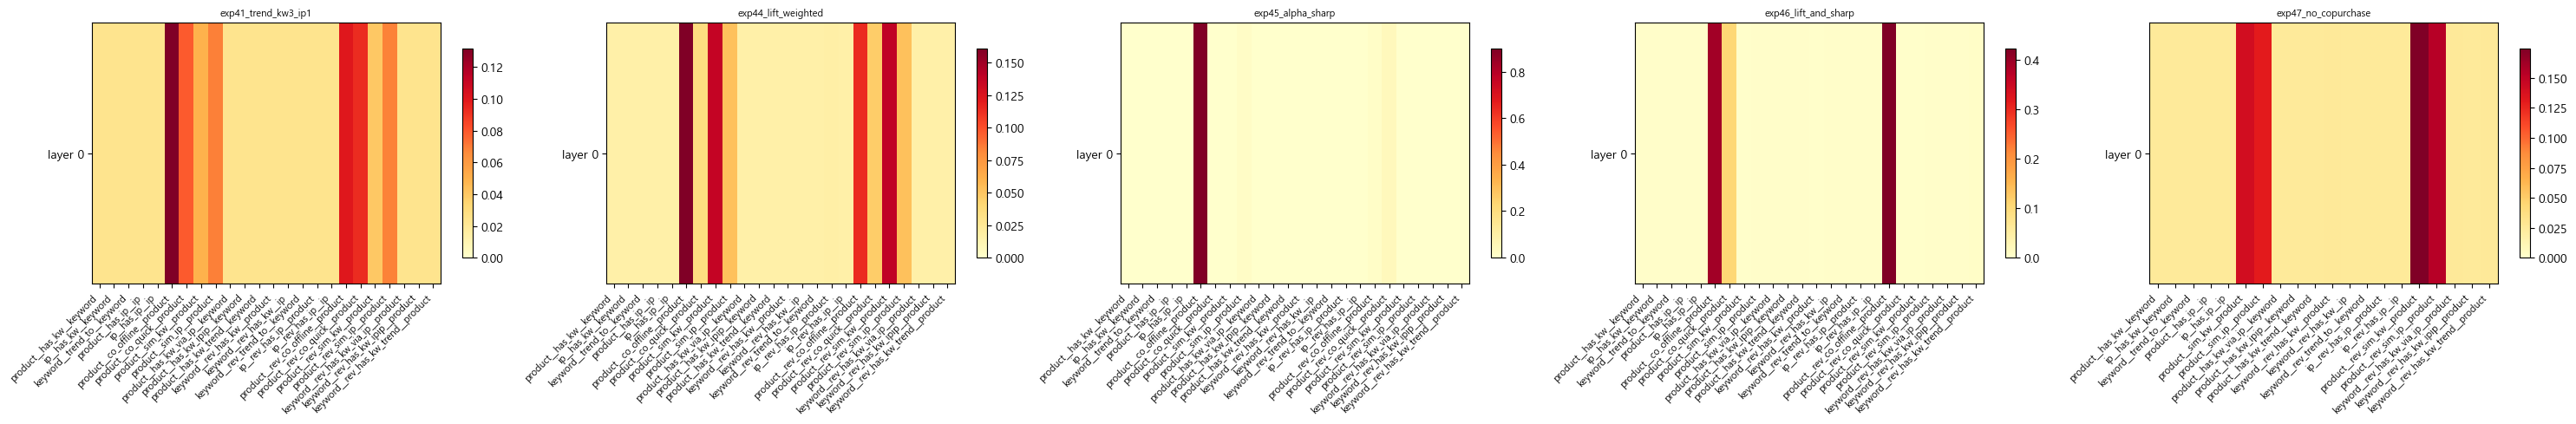

In [18]:
# α 히트맵 시각화
done = [n for n in all_names if os.path.exists(f'experiments/results/{n}/relation_importance.json')]
fig, axes = plt.subplots(1, len(done), figsize=(len(done)*6, 5))
if len(done) == 1:
    axes = [axes]
for ax, name in zip(axes, done):
    try:
        plot_alpha_heatmap(name, ax=ax)
        ax.set_title(name, fontsize=8)
    except Exception as e:
        ax.set_title(f'{name}\n오류: {e}')
plt.tight_layout()
plt.show()

---
## 최종 모델 선정

**선정 기준**:
1. test PR-AUC ≥ 0.6959 또는 -0.005 이내 (성능)
2. val-test gap < 0.040 (일반화)
3. 키워드 α_r 표준편차 > 0.003 (분화 — 해석력)

**exp47 추가 해석 기준**:
- 성능 하락폭이 크면 → 공동구매가 핵심 신호, exp41 유지
- 키워드 α_r 분화되면 → 키워드 경로 해석을 위해 별도 서빙 모델로 활용 가능

In [ ]:
PERF_FLOOR    = 0.6959 - 0.005
GAP_CEILING   = 0.040
ALPHA_STD_MIN = 0.003

rows = []
for name in all_names:
    try:
        m = load_experiment(name)['metrics']
        a = load_alpha_stats(name)
        test_pr = m['test']['pr_auc']
        gap     = m['val']['pr_auc'] - test_pr
        kw_std  = a['kw_std'] if a else float('nan')
        ok_perf  = test_pr >= PERF_FLOOR
        ok_gap   = gap < GAP_CEILING
        ok_alpha = kw_std > ALPHA_STD_MIN
        rows.append(dict(
            exp=name,
            test_pr_auc=round(test_pr, 4),
            gap=round(gap, 4),
            kw_std=round(kw_std, 5),
            성능=('✅' if ok_perf else '❌'),
            일반화=('✅' if ok_gap else '❌'),
            분화=('✅' if ok_alpha else '❌'),
            통과=('★' if (ok_perf and ok_gap and ok_alpha) else
                   '△' if (ok_perf and ok_gap) else '✗'),
        ))
    except FileNotFoundError:
        rows.append(dict(exp=name, test_pr_auc=None, gap=None, kw_std=None,
                         성능='?', 일반화='?', 분화='?', 통과='미실행'))

df_verdict = pd.DataFrame(rows)
try:
    display(df_verdict)
except Exception:
    print(df_verdict.to_string(index=False))

winners = df_verdict[df_verdict['통과'] == '★']
if len(winners):
    best = winners.sort_values('test_pr_auc', ascending=False).iloc[0]
    print(f"\n★ 최종 모델 후보: {best['exp']}")
    print(f"  test PR-AUC={best['test_pr_auc']}, gap={best['gap']}, kw_std={best['kw_std']}")
else:
    cand = df_verdict[df_verdict['통과'] == '△']
    if len(cand):
        best = cand.sort_values('test_pr_auc', ascending=False).iloc[0]
        print(f"\n△ 분화 기준 미달 — 성능/일반화 기준 통과: {best['exp']}")
        print("  → exp41(기준선)과 비교 후 최종 결정 필요")
    else:
        print("\n모든 실험 기준 미달 → exp41 유지")